In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score,KFold
from sklearn.preprocessing import StandardScaler
from scipy.stats import norm
from scipy.ndimage import gaussian_filter1d
import math
from pygam import LinearGAM, s

In [40]:
df = pd.read_csv('Dataset_modelo_Causalidad.csv')
 
TRATAMIENTO = 'NDVI'
OUTCOME     = 'LST_Celsius'
 
CONFUSORES_GPS = [
    'FAR', 'Elevation', 'NTL', 'Impermeabilidad', 
    'Wind_Speed', 'Log_Dist_Road_m', 
    'Uso_Bosques_Naturaleza', 'Uso_Humedales', 
    'latitude', 'longitude','Uso_Agua'
]

In [41]:
cols_disponibles = [c for c in CONFUSORES_GPS if c in df.columns]
cols_faltantes   = [c for c in CONFUSORES_GPS if c not in df.columns]
if cols_faltantes:
    print(f"Columnas no encontradas: {cols_faltantes}")
CONFUSORES_GPS = cols_disponibles

Columnas no encontradas: ['Uso_Bosques_Naturaleza', 'Uso_Humedales']


In [42]:
df_clean = df[CONFUSORES_GPS + [TRATAMIENTO, OUTCOME]].dropna().copy()
print(f"Píxeles para el GPS: {len(df_clean):,}")
 
X = df_clean[CONFUSORES_GPS].values
T = df_clean[TRATAMIENTO].values
Y = df_clean[OUTCOME].values

Píxeles para el GPS: 282,414


In [43]:
print("\n── Paso 1: Modelo de exposición ──")
 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
 
modelo_exposicion = XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,       # regularización L1 — evita sobreajuste
    reg_lambda=1.0,      # regularización L2
    min_child_weight=20, # equivalente a min_samples_leaf — evita nodos muy pequeños
    random_state=42,
    n_jobs=-1            # usa todos los cores disponibles
)
modelo_exposicion.fit(X_scaled, T)



── Paso 1: Modelo de exposición ──


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [44]:
r2_cv = cross_val_score(
    modelo_exposicion, X_scaled, T,
    cv=5, scoring='r2'
).mean()
print(f"R² XGBoost cross-validation: {r2_cv:.3f}")

T_hat = modelo_exposicion.predict(X_scaled)
residuos = T - T_hat

R² XGBoost cross-validation: 0.478


In [45]:
feat_imp = pd.Series(
    modelo_exposicion.feature_importances_,
    index=CONFUSORES_GPS
).sort_values(ascending=False)
print("\nImportancia de confusores (XGBoost):")
print(feat_imp.round(3))


Importancia de confusores (XGBoost):
Impermeabilidad    0.602
FAR                0.195
NTL                0.071
Wind_Speed         0.035
longitude          0.026
Log_Dist_Road_m    0.026
latitude           0.022
Uso_Agua           0.012
Elevation          0.012
dtype: float32


In [46]:
print(f"NDVI observado  — media: {T.mean():.3f}, std: {T.std():.3f}")
print(f"NDVI predicho   — media: {T_hat.mean():.3f}, std: {T_hat.std():.3f}")
print(f"Residuos        — media: {residuos.mean():.4f}, std: {residuos.std():.3f}")

NDVI observado  — media: 0.452, std: 0.208
NDVI predicho   — media: 0.452, std: 0.166
Residuos        — media: 0.0000, std: 0.116


In [47]:
print("\n── Paso 2: Cálculo del GPS ──")
 
sigma_hat = residuos.std()
gps = norm.pdf(T, loc=T_hat, scale=sigma_hat)
 
df_clean['T_hat']    = T_hat
df_clean['residuos'] = residuos
df_clean['GPS']      = gps
 
print(f"GPS — media: {gps.mean():.4f}, std: {gps.std():.4f}")
print(f"GPS — min: {gps.min():.6f}, max: {gps.max():.4f}")


── Paso 2: Cálculo del GPS ──
GPS — media: 2.4574, std: 0.9587
GPS — min: 0.000039, max: 3.4251


In [48]:
pct_bajo  = (gps < np.percentile(gps, 10)).mean() * 100
pct_alto  = (gps > np.percentile(gps, 90)).mean() * 100
print(f"Píxeles con GPS bajo (p10):  {pct_bajo:.1f}% — anomalías urbanas")
print(f"Píxeles con GPS alto (p90):  {pct_alto:.1f}% — vegetación 'normal'")

Píxeles con GPS bajo (p10):  10.0% — anomalías urbanas
Píxeles con GPS alto (p90):  10.0% — vegetación 'normal'


In [49]:
print("\n── Paso 3: Pesos IPW ──")
 
# Densidad marginal de T (sin condicionar en X)
marginal_density = norm.pdf(T, loc=T.mean(), scale=T.std())
 
# Peso estabilizado (más robusto que 1/GPS puro)
weights_raw = marginal_density / gps
 
# Trim de pesos extremos (percentil 1–99) para estabilidad numérica
p1  = np.percentile(weights_raw, 1)
p99 = np.percentile(weights_raw, 99)
weights = np.clip(weights_raw, p1, p99)
 
# Normalizar
weights = weights / weights.mean()
 
df_clean['weights'] = weights
 
print(f"Pesos — media: {weights.mean():.3f}, std: {weights.std():.3f}")
print(f"Pesos — min: {weights.min():.3f}, max: {weights.max():.3f}")


── Paso 3: Pesos IPW ──
Pesos — media: 1.000, std: 1.797
Pesos — min: 0.145, max: 14.139


In [50]:
print("\nBalance de confusores (|correlación con NDVI|):")
print(f"{'Variable':<20} {'Antes GPS':>10} {'Después GPS':>12}")
print("-" * 44)
for col in CONFUSORES_GPS:
    corr_antes  = abs(np.corrcoef(df_clean[col], T)[0,1])
    corr_despues = abs(np.cov(df_clean[col], T,
                              aweights=weights)[0,1] /
                       (df_clean[col].std() * T.std()))
    flag = " ✓" if corr_despues < corr_antes else " !"
    print(f"  {col:<18} {corr_antes:>10.3f} {corr_despues:>12.3f}{flag}")


Balance de confusores (|correlación con NDVI|):
Variable              Antes GPS  Después GPS
--------------------------------------------
  FAR                     0.642        0.076 ✓
  Elevation               0.241        0.047 ✓
  NTL                     0.587        0.082 ✓
  Impermeabilidad         0.714        0.075 ✓
  Wind_Speed              0.307        0.042 ✓
  Log_Dist_Road_m         0.401        0.066 ✓
  latitude                0.237        0.046 ✓
  longitude               0.198        0.011 ✓
  Uso_Agua                0.033        0.014 ✓


In [111]:

 
print("\n── Paso 4: ADRF — Función dosis-respuesta ──")
print("\n── Paso 4: ADRF — Función dosis-respuesta ──")

mask_urban = df_clean['NDVI'] > 0.01
T_urban = T[mask_urban]
Y_urban = Y[mask_urban]
W_urban = weights[mask_urban]

print(f"Píxeles en rango urbano (NDVI > 0.05): {mask_urban.sum():,}")
print(f"Píxeles excluidos (agua/suelo desnudo): {(~mask_urban).sum():,}")


idx_sort = np.argsort(T_urban)
T_sort   = T_urban[idx_sort]
Y_sort   = Y_urban[idx_sort]
W_sort   = W_urban[idx_sort]

# GAM ponderado: LST ~ s(NDVI)
gam = LinearGAM(s(0, n_splines=10, spline_order=3))
gam.fit(T_sort.reshape(-1,1), Y_sort, weights=W_sort)

# Grid de predicción para la curva ADRF
t_grid = np.linspace(T_urban.min(), T_urban.max(), 300)

# CORRECCIÓN AQUÍ: predict() solo devuelve las predicciones
lst_pred = gam.predict(t_grid.reshape(-1,1))

# confidence_intervals() calcula la banda del 95%
ci = gam.confidence_intervals(t_grid.reshape(-1,1), width=0.95)

print(f"GAM R²: {gam.statistics_['pseudo_r2']['explained_deviance']:.3f}")


── Paso 4: ADRF — Función dosis-respuesta ──

── Paso 4: ADRF — Función dosis-respuesta ──
Píxeles en rango urbano (NDVI > 0.05): 282,381
Píxeles excluidos (agua/suelo desnudo): 33
GAM R²: 0.246


In [112]:
delta_t   = 0.1
lst_base  = gam.predict(np.array([[0.3]]))
lst_high  = gam.predict(np.array([[0.4]]))
efecto_marginal = (lst_high - lst_base)[0]
print(f"\nEfecto marginal estimado:")
print(f"  NDVI 0.3 → 0.4 : {efecto_marginal:+.2f} °C")
 
# Punto de saturación (donde la derivada ≈ 0)
derivada = np.gradient(lst_pred, t_grid)
idx_sat  = np.where(np.abs(derivada) < 0.05)[0]
if len(idx_sat) > 0:
    ndvi_sat = t_grid[idx_sat[0]]
    print(f"  Punto de saturación: NDVI ≈ {ndvi_sat:.2f}")
else:
    print("  No se detectó punto de saturación claro")
 


Efecto marginal estimado:
  NDVI 0.3 → 0.4 : -0.54 °C
  Punto de saturación: NDVI ≈ 0.07


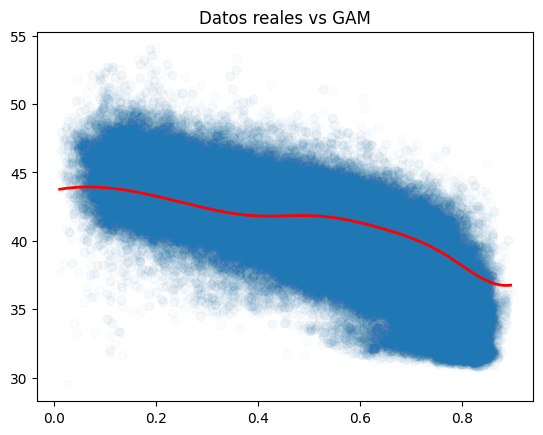

In [113]:
plt.scatter(T_urban, Y_urban, alpha=0.02)
plt.plot(t_grid, lst_pred, color='red', linewidth=2)
plt.title("Datos reales vs GAM")
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_7932\720117645.py:44: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\PC\AppData\Local\Temp\ipykernel_7932\720117645.py:45: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('gps_pipeline_results.png', dpi=150, bbox_inches='tight')
c:\Users\PC\miniconda3\envs\deep\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


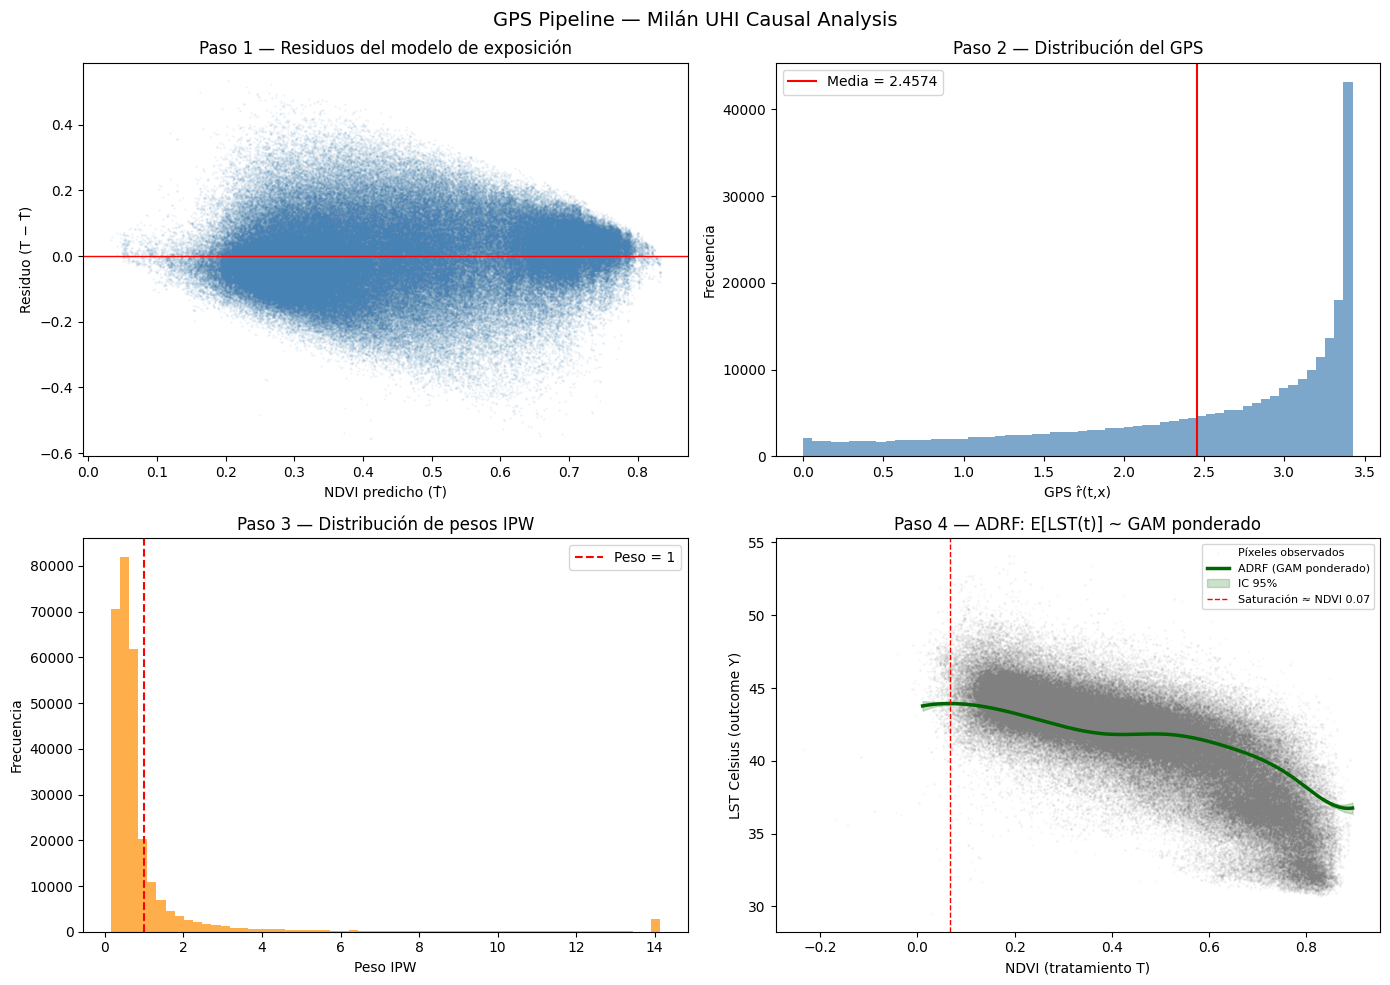


Gráfico guardado: gps_pipeline_results.png


In [114]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('GPS Pipeline — Milán UHI Causal Analysis', fontsize=14)
 
# Panel 1: Residuos del modelo de exposición
ax1 = axes[0, 0]
ax1.scatter(T_hat, residuos, alpha=0.05, s=1, color='steelblue')
ax1.axhline(0, color='red', linewidth=1)
ax1.set_xlabel('NDVI predicho (T̂)')
ax1.set_ylabel('Residuo (T − T̂)')
ax1.set_title('Paso 1 — Residuos del modelo de exposición')
 
# Panel 2: Distribución del GPS
ax2 = axes[0, 1]
ax2.hist(gps, bins=60, color='steelblue', alpha=0.7, edgecolor='none')
ax2.axvline(gps.mean(), color='red', linewidth=1.5, label=f'Media = {gps.mean():.4f}')
ax2.set_xlabel('GPS r̂(t,x)')
ax2.set_ylabel('Frecuencia')
ax2.set_title('Paso 2 — Distribución del GPS')
ax2.legend()
 
# Panel 3: Distribución de pesos
ax3 = axes[1, 0]
ax3.hist(weights, bins=60, color='darkorange', alpha=0.7, edgecolor='none')
ax3.axvline(1.0, color='red', linewidth=1.5, linestyle='--', label='Peso = 1')
ax3.set_xlabel('Peso IPW')
ax3.set_ylabel('Frecuencia')
ax3.set_title('Paso 3 — Distribución de pesos IPW')
ax3.legend()
 
# Panel 4: ADRF — curva dosis-respuesta
ax4 = axes[1, 1]
ax4.scatter(T, Y, alpha=0.03, s=1, color='gray', label='Píxeles observados')
ax4.plot(t_grid, lst_pred, color='darkgreen', linewidth=2.5, label='ADRF (GAM ponderado)')
ax4.fill_between(t_grid, ci[:, 0], ci[:, 1],
                 alpha=0.2, color='darkgreen', label='IC 95%')
ax4.axvline(ndvi_sat if len(idx_sat) > 0 else 0.6,
            color='red', linestyle='--', linewidth=1,
            label=f'Saturación ≈ NDVI {ndvi_sat:.2f}' if len(idx_sat) > 0 else '')
ax4.set_xlabel('NDVI (tratamiento T)')
ax4.set_ylabel('LST Celsius (outcome Y)')
ax4.set_title('Paso 4 — ADRF: E[LST(t)] ~ GAM ponderado')
ax4.legend(fontsize=8)
 
plt.tight_layout()
plt.savefig('gps_pipeline_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nGráfico guardado: gps_pipeline_results.png")

### Validaciones

In [115]:
print("\n── Tabla de Efectos Marginales (+0.1 NDVI) ──")
tramos = [0.1, 0.3, 0.5, 0.7]
for base in tramos:
    lst_base = gam.predict(np.array([[base]]))
    lst_alta = gam.predict(np.array([[base + 0.1]]))
    caida = (lst_alta - lst_base)[0]
    print(f"  Pasar de {base:.1f} a {base+0.1:.1f} : {caida:+.2f} °C")


── Tabla de Efectos Marginales (+0.1 NDVI) ──
  Pasar de 0.1 a 0.2 : -0.62 °C
  Pasar de 0.3 a 0.4 : -0.54 °C
  Pasar de 0.5 a 0.6 : -0.52 °C
  Pasar de 0.7 a 0.8 : -2.04 °C


Tramo NDVI                             Efecto marginal (°C / +0.1 NDVI)
-------------------------------------------------------------------------------------
Suelo casi desnudo                -0.335 °C   [-0.291, -0.379]
Vegetación escasa                 -0.901 °C   [-0.897, -0.905]
Vegetación moderada               -0.308 °C   [-0.308, -0.308]
Vegetación densa                  -0.342 °C   [-0.343, -0.341]
Parques / bosque urbano           -1.527 °C   [-1.570, -1.483]

Umbral estimado: NDVI ≈ 0.323


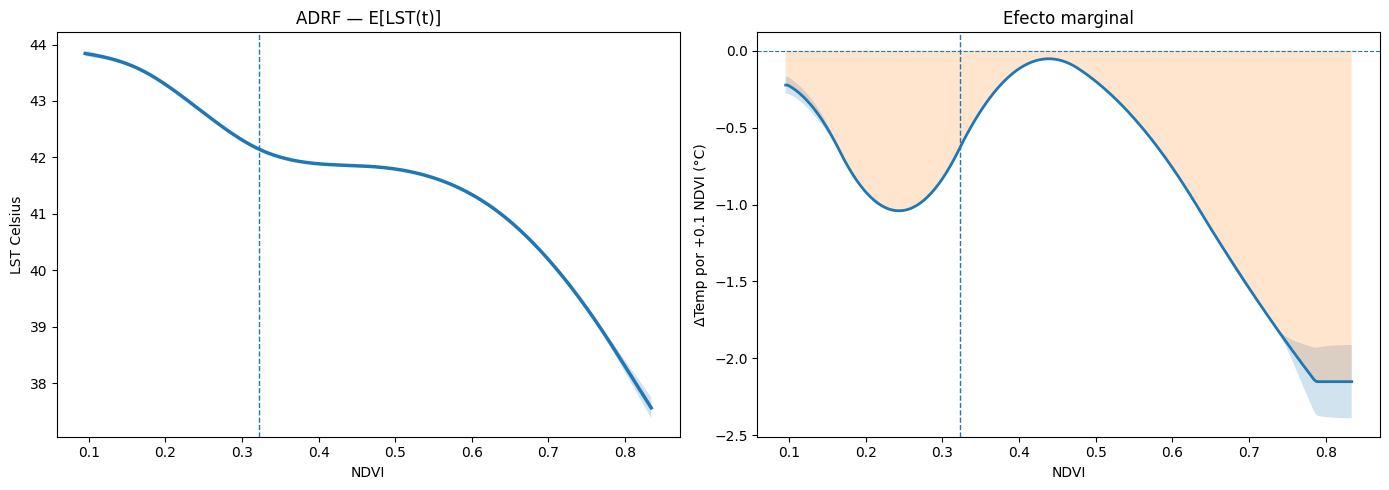

In [94]:
# ─────────────────────────────────────────────
# Grid limpio (evitar extremos)
# ─────────────────────────────────────────────
t_grid = np.linspace(np.percentile(T, 1), np.percentile(T, 99), 300)

# Predicción ADRF
lst_pred = gam.predict(t_grid.reshape(-1, 1))

# Intervalos de confianza de la curva
ci = gam.confidence_intervals(t_grid.reshape(-1, 1), width=0.95)

# ─────────────────────────────────────────────
# DERIVADA NUMÉRICA (mejorada)
# ─────────────────────────────────────────────

dt = t_grid[1] - t_grid[0]

# derivada central (más estable que gradient simple)
deriv = np.zeros_like(lst_pred)
deriv[1:-1] = (lst_pred[2:] - lst_pred[:-2]) / (2 * dt)
deriv[0] = deriv[1]
deriv[-1] = deriv[-2]

# ── Derivada para los límites del IC
ci_low = ci[:, 0]
ci_high = ci[:, 1]

deriv_low = np.zeros_like(ci_low)
deriv_high = np.zeros_like(ci_high)

deriv_low[1:-1] = (ci_low[2:] - ci_low[:-2]) / (2 * dt)
deriv_high[1:-1] = (ci_high[2:] - ci_high[:-2]) / (2 * dt)

deriv_low[0] = deriv_low[1]
deriv_low[-1] = deriv_low[-2]

deriv_high[0] = deriv_high[1]
deriv_high[-1] = deriv_high[-2]

# Escalar a +0.1 NDVI
deriv_scaled = deriv * 0.1
deriv_ci_scaled = np.column_stack([deriv_low * 0.1, deriv_high * 0.1])

# ─────────────────────────────────────────────
# Tabla de efectos marginales
# ─────────────────────────────────────────────

tramos = [
    (0.05, 0.15, 'Suelo casi desnudo'),
    (0.15, 0.30, 'Vegetación escasa'),
    (0.30, 0.45, 'Vegetación moderada'),
    (0.45, 0.60, 'Vegetación densa'),
    (0.60, 0.80, 'Parques / bosque urbano'),
]

print(f"{'Tramo NDVI':<35} {'Efecto marginal (°C / +0.1 NDVI)':>35}")
print("-" * 85)

for t_low, t_high, label in tramos:
    mask = (t_grid >= t_low) & (t_grid < t_high)

    efecto = deriv_scaled[mask].mean()
    ci_l = deriv_ci_scaled[mask, 0].mean()
    ci_h = deriv_ci_scaled[mask, 1].mean()

    print(f"{label:<33} {efecto:+.3f} °C   [{ci_l:.3f}, {ci_h:.3f}]")

# ─────────────────────────────────────────────
# Umbral basado en cambio de pendiente
# ─────────────────────────────────────────────

cambio = np.gradient(deriv)
idx_umbral = np.argmax(np.abs(cambio))
ndvi_umbral = t_grid[idx_umbral]

print(f"\nUmbral estimado: NDVI ≈ {ndvi_umbral:.3f}")

# ─────────────────────────────────────────────
# Visualización
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ADRF
ax1 = axes[0]
ax1.plot(t_grid, lst_pred, linewidth=2.5)
ax1.fill_between(t_grid, ci[:, 0], ci[:, 1], alpha=0.2)
ax1.axvline(ndvi_umbral, linestyle='--', linewidth=1)

ax1.set_xlabel('NDVI')
ax1.set_ylabel('LST Celsius')
ax1.set_title('ADRF — E[LST(t)]')

# Derivada
ax2 = axes[1]
ax2.plot(t_grid, deriv_scaled, linewidth=2)
ax2.fill_between(t_grid, deriv_ci_scaled[:, 0], deriv_ci_scaled[:, 1], alpha=0.2)

ax2.axhline(0, linestyle='--', linewidth=0.8)
ax2.axvline(ndvi_umbral, linestyle='--', linewidth=1)

ax2.fill_between(
    t_grid,
    deriv_scaled,
    0,
    where=(deriv_scaled < 0),
    alpha=0.2
)

ax2.set_xlabel('NDVI')
ax2.set_ylabel('ΔTemp por +0.1 NDVI (°C)')
ax2.set_title('Efecto marginal')

plt.tight_layout()
plt.show()

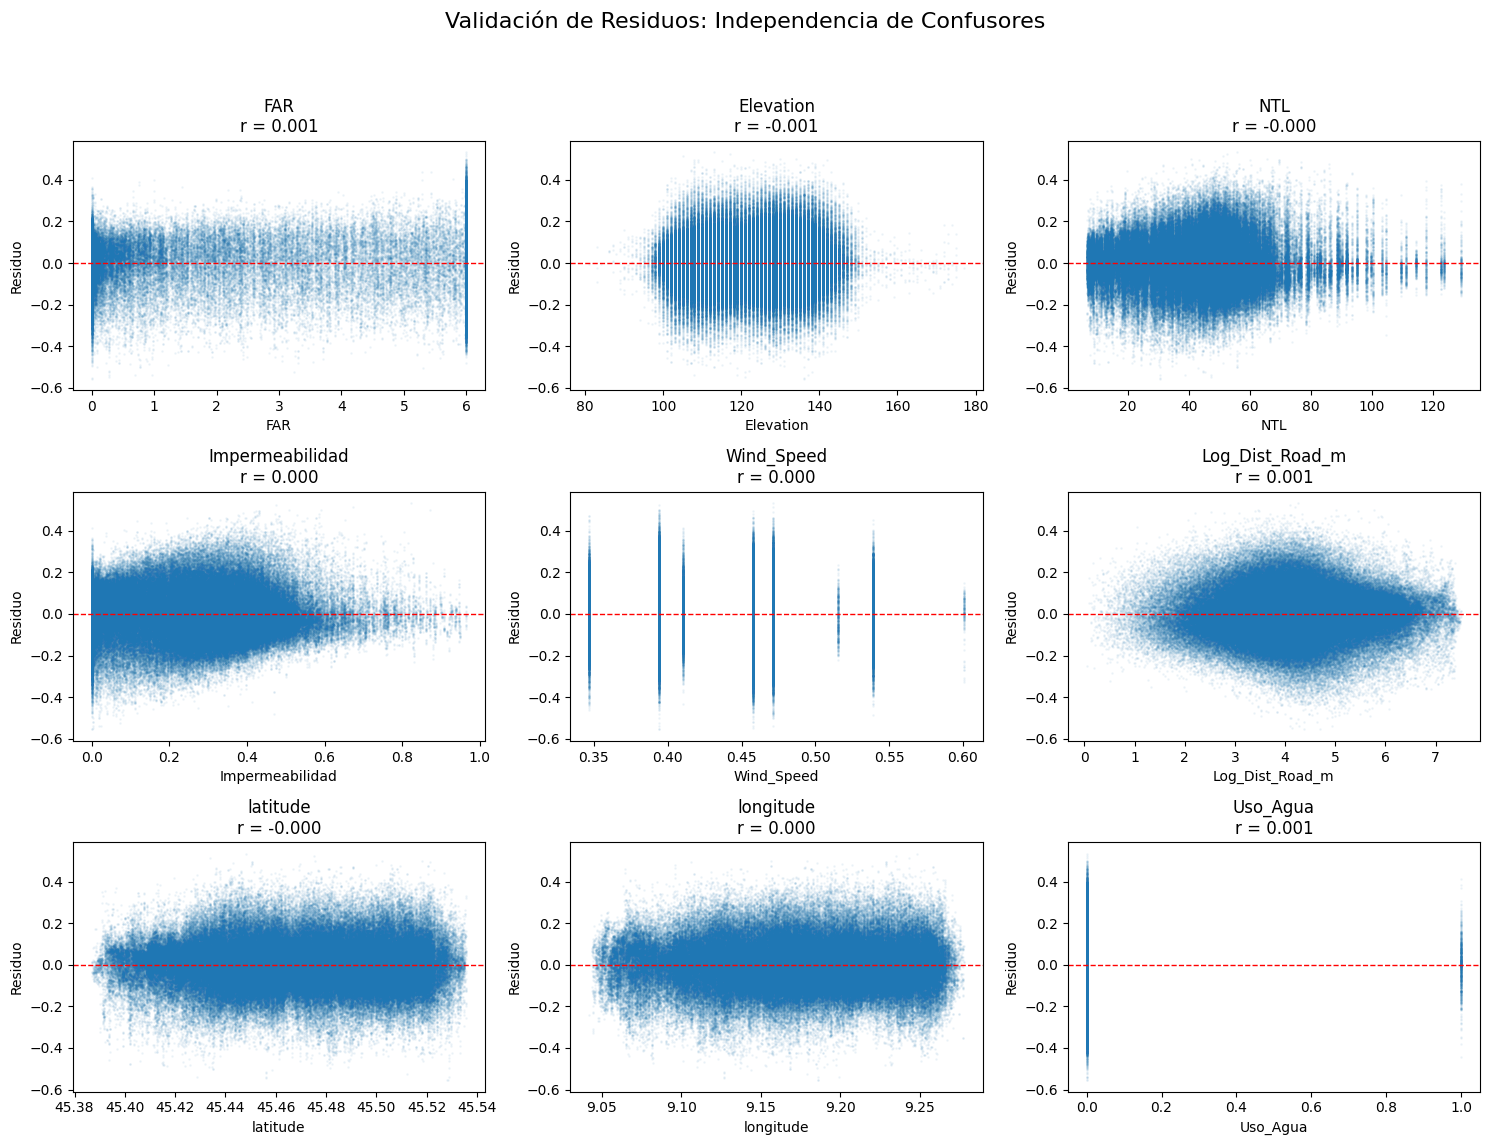

In [95]:
n_vars = len(CONFUSORES_GPS)
n_cols = 3
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten() # Aplana la matriz para iterar fácilmente

for i, col in enumerate(CONFUSORES_GPS):
    ax = axes[i]
    ax.scatter(df_clean[col], residuos, alpha=0.05, s=1)
    ax.axhline(0, color='red', linewidth=1, linestyle='--')
    ax.set_xlabel(col)
    ax.set_ylabel('Residuo')
    
    # Calcular correlación omitiendo NaNs si los hay
    corr = np.corrcoef(df_clean[col], residuos)[0,1]
    ax.set_title(f'{col}\nr = {corr:.3f}')

# Limpiar subplots vacíos si n_vars no es múltiplo de 3
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Validación de Residuos: Independencia de Confusores', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [96]:
# 2a. Correlación de Spearman antes y después de ponderar
from scipy.stats import spearmanr

print(f"{'Variable':<22} {'Antes':>8} {'Después':>10} {'Mejoró?':>10}")
print("-" * 52)
for col in CONFUSORES_GPS:
    r_antes,  _ = spearmanr(df_clean[col], T)
    r_despues, _ = spearmanr(df_clean[col], T,
                              alternative='two-sided')
    # correlación ponderada manual
    w_norm = weights / weights.sum()
    mu_x = np.average(df_clean[col], weights=w_norm)
    mu_t = np.average(T, weights=w_norm)
    cov  = np.average((df_clean[col]-mu_x)*(T-mu_t), weights=w_norm)
    r_w  = cov / (df_clean[col].std() * T.std())

    mejora = abs(r_w) < abs(r_antes)
    print(f"  {col:<20} {r_antes:>8.3f} {r_w:>10.3f}  {'✓' if mejora else '✗'}")

# 2b. Standardized Mean Difference (SMD) — estándar en literatura de PS
# SMD < 0.1 después de ponderar = balance aceptable
print("\nSMD (Standardized Mean Difference) — debe ser < 0.1 después de GPS:")
import numpy as np

# Asegúrate de que T sea un array de numpy
T = df_clean['NDVI'].values 

for col in CONFUSORES_GPS:
    x = df_clean[col].values
    
    # Calcular la mediana global del tratamiento
    t_med = np.median(T)
    
    # Índices para los grupos "Tratados" (Alta vegetación) y "Control" (Baja vegetación)
    idx_high = T > t_med
    idx_low = T <= t_med
    
    # SMD Antes (Sin pesos)
    smd_antes = (x[idx_high].mean() - x[idx_low].mean()) / x.std()
    
    # SMD Después (Ponderado por el GPS / Pesos)
    # Suponiendo que tu variable de pesos se llama 'weights'
    w_high = weights[idx_high]
    w_low = weights[idx_low]
    
    mean_w_high = np.average(x[idx_high], weights=w_high)
    mean_w_low = np.average(x[idx_low], weights=w_low)
    
    smd_despues = (mean_w_high - mean_w_low) / x.std()
    
    print(f"{col:20} Antes: {smd_antes:7.3f} | Después: {smd_despues:7.3f} | {'✓' if abs(smd_despues) < 0.1 else '✗'}")


Variable                  Antes    Después    Mejoró?
----------------------------------------------------
  FAR                    -0.642     -0.076  ✓
  Elevation              -0.221     -0.047  ✓
  NTL                    -0.600     -0.082  ✓
  Impermeabilidad        -0.722     -0.075  ✓
  Wind_Speed              0.321      0.042  ✓
  Log_Dist_Road_m         0.399      0.066  ✓
  latitude               -0.214     -0.046  ✓
  longitude              -0.182     -0.011  ✓
  Uso_Agua                0.033      0.014  ✓

SMD (Standardized Mean Difference) — debe ser < 0.1 después de GPS:
FAR                  Antes:  -1.083 | Después:  -0.061 | ✓
Elevation            Antes:  -0.414 | Después:  -0.068 | ✓
NTL                  Antes:  -0.990 | Después:  -0.068 | ✓
Impermeabilidad      Antes:  -1.245 | Después:  -0.039 | ✓
Wind_Speed           Antes:   0.520 | Después:   0.026 | ✓
Log_Dist_Road_m      Antes:   0.691 | Después:   0.083 | ✓
latitude             Antes:  -0.402 | Después:  -0.062 |

In [97]:
print(gam.summary())

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      7.6319
Link Function:                     IdentityLink Log Likelihood:                              -1239151.3452
Number of Samples:                       268262 AIC:                                          2478319.9542
                                                AICc:                                         2478319.9548
                                                GCV:                                                5.6141
                                                Scale:                                              2.3693
                                                Pseudo R-Squared:                                   0.1923
Feature Function                  Lam

C:\Users\PC\AppData\Local\Temp\ipykernel_7932\3564666153.py:1: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam.summary())


In [98]:
p_values = gam.statistics_['p_values']
print("p-values:", p_values)

p-values: [np.float64(0.0), np.float64(0.0)]


In [99]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    T.reshape(-1,1), Y, weights, test_size=0.2, random_state=42
)

gam_cv = LinearGAM(s(0, n_splines=15)).fit(X_train, y_train, weights=w_train)

r2_test = gam_cv.score(X_test, y_test)
print(f"GAM R² en test: {r2_test:.3f}")

GAM R² en test: 0.467


Sensibilidad de la ADRF al número de splines:
  n_splines=6: LST en [0.3, 0.4, 0.5, 0.6] = [42.31 41.94 41.77 41.32]
  n_splines=8: LST en [0.3, 0.4, 0.5, 0.6] = [42.31 41.89 41.8  41.34]
  n_splines=10: LST en [0.3, 0.4, 0.5, 0.6] = [42.35 41.84 41.81 41.35]
  n_splines=12: LST en [0.3, 0.4, 0.5, 0.6] = [42.34 41.83 41.84 41.31]


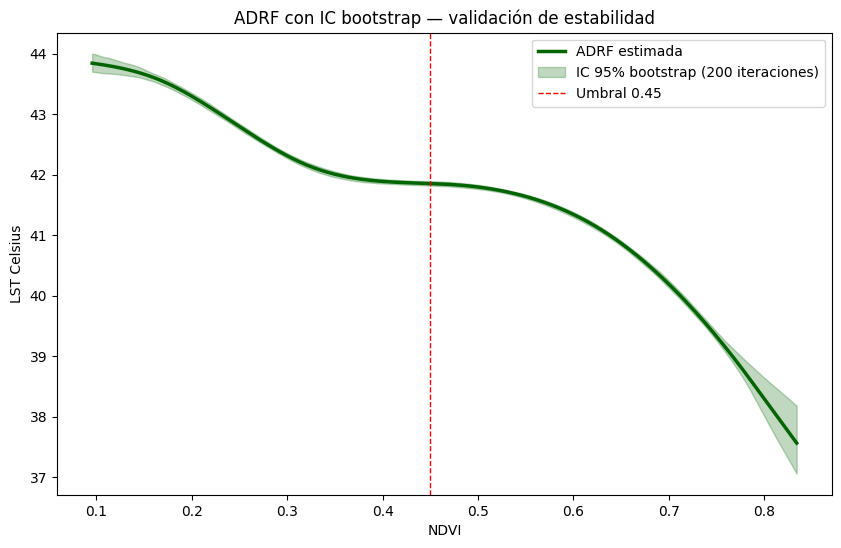

In [100]:
# 3a. Sensibilidad al número de splines
print("Sensibilidad de la ADRF al número de splines:")
t_test = np.array([[0.3], [0.4], [0.5], [0.6]])

for n_sp in [6, 8, 10, 12]:
    gam_test = LinearGAM(s(0, n_splines=n_sp, spline_order=3))
    gam_test.fit(T_sort.reshape(-1,1), Y_sort, weights=W_sort)
    preds = gam_test.predict(t_test)
    print(f"  n_splines={n_sp}: LST en [0.3, 0.4, 0.5, 0.6] = "
          f"{preds.round(2)}")
# Si los valores cambian mucho entre n_splines → curva inestable

# 3b. Bootstrap de la curva ADRF — intervalos de confianza empíricos
from sklearn.utils import resample

n_boot = 200
lst_boot = np.zeros((n_boot, len(t_grid)))

for b in range(n_boot):
    idx_b = resample(np.arange(len(T_urban)), random_state=b)
    T_b, Y_b, W_b = T_urban[idx_b], Y_urban[idx_b], W_urban[idx_b]
    idx_s = np.argsort(T_b)
    gam_b = LinearGAM(s(0, n_splines=8, spline_order=3))
    gam_b.fit(T_b[idx_s].reshape(-1,1), Y_b[idx_s], weights=W_b[idx_s])
    lst_boot[b] = gam_b.predict(t_grid.reshape(-1,1))

ci_low  = np.percentile(lst_boot, 2.5,  axis=0)
ci_high = np.percentile(lst_boot, 97.5, axis=0)

plt.figure(figsize=(10, 6))
plt.plot(t_grid, lst_pred, color='darkgreen', linewidth=2.5,
         label='ADRF estimada')
plt.fill_between(t_grid, ci_low, ci_high,
                 alpha=0.25, color='darkgreen',
                 label='IC 95% bootstrap (200 iteraciones)')
plt.axvline(0.45, color='red', linestyle='--', linewidth=1,
            label='Umbral 0.45')
plt.xlabel('NDVI')
plt.ylabel('LST Celsius')
plt.title('ADRF con IC bootstrap — validación de estabilidad')
plt.legend()
plt.savefig('adrf_bootstrap.png', dpi=150)
plt.show()

In [116]:
df_clean.to_csv('Milan_Causal_Dataset_GPS.csv', index=False)
